In [2]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import yaml
import helpers_eda_inicial
import unicodedata
from helpers_finalizacion_carrera import get_porcentaje_aprobadas, get_materias_fuera_de_carrera, plot_optativas_por_anio, get_egresados, plot_egresados_por_anio

/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/solcalloni/Documents/github/modelos-para-prediccion-de-abandono/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [4]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

## Computación

In [5]:
materias_computacion = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias de la Computación']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_computacion

,materia,cantidad
0,ALGEBRA I,10599
1,ANALISIS II,7125
2,PROBABILIDADES Y ESTADISTICA,5038
3,ALGORITMOS Y ESTRUCTURAS DE DATOS II,4531
4,ALGORITMOS Y ESTRUCTURAS DE DATOS I,4362
...,...,...
350,REDUCCIONES Y CAUSALIDAD,1
351,FISICA DE ESTADISTICA DE LOS SISTEMAS SOCIO-EC...,1
352,MODELOS MATEMATICOS Y OPTIMIZACION,1
353,INTRODUCCION A LA FOTOGRAFIA 3D,1


In [6]:
with open('../../constants/materias_computacion.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [7]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias = list(set(materias))
materias

['SISTEMAS DIGITALES',
 'ANALISIS II',
 'INGENIERIA DE SOFTWARE',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS III',
 'PROBABILIDADES Y ESTADISTICA',
 'SISTEMAS OPERATIVOS',
 'TEORIA DE LENGUAJES',
 'PROGRAMACION CONCURRENTE Y PARALELA',
 'LOGICA Y COMPUTABILIDAD',
 'TEORIA DE LAS COMUNICACIONES',
 'METODOS NUMERICOS',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS I',
 'TECNICAS DE DISENO DE ALGORITMOS',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION',
 'ALGEBRA I',
 'PARADIGMAS DE PROGRAMACION',
 'ARQUITECTURA Y ORGANIZACION DE COMPUTADORES',
 'SEMINARIO SOBRE TECNOLOGIA Y SOCIEDAD',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS II',
 'COMPLEJIDAD COMPUTACIONAL',
 'ESTADISTICA COMPUTACIONAL',
 'ORGANIZACION DEL COMPUTADOR I',
 'ALGEBRA LINEAL COMPUTACIONAL',
 'PRACTICA SOCIAL EDUCATIVA',
 'ANALISIS I',
 'LENGUAJES FORMALES, AUTOMATAS Y COMPUTABILIDAD',
 'ORGANIZACION DEL COMPUTADOR II',
 'REDES DE COMUNICACIONES Y COMPUTO DISTRIBUIDO',
 'INTRODUCCION A LA PROGRAMACION',
 'INGENIERIA DE SOFTWARE I',
 'ALGORITMO

In [8]:
len(materias)

34

In [9]:
materias_computacion[materias_computacion['materia'].isin(materias)].shape

(29, 2)

No todas las carreras aparecen, revisamos cuales faltan

In [10]:
materias_en_actas = materias_computacion['materia'].tolist()

In [11]:
[m for m in materias if m not in materias_en_actas]

['PROGRAMACION CONCURRENTE Y PARALELA',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION',
 'ESTADISTICA COMPUTACIONAL',
 'PRACTICA SOCIAL EDUCATIVA',
 'REDES DE COMUNICACIONES Y COMPUTO DISTRIBUIDO']

In [12]:
materias_computacion[materias_computacion['materia'].isin(materias)].sort_values(by='cantidad', ascending=False).shape

(29, 2)

Todas se corresponden con materias del nuevo plan de computación, que ninguna de las materias puede estar indicando que todavía no se dieron.

A su vez, todas estas materias tienen correlativa excepto 'PRACTICA SOCIAL EDUCATIVA'. Esto nos daría el indicio de que no hay egresados con el nuevo plan todavía.

In [13]:
df_obligatorias = get_porcentaje_aprobadas(
                    carreras=['Licenciatura en Ciencias de la Computación'],
                    anio=2010,
                    path_yaml='../../constants/materias_computacion.yaml'
)

In [14]:
df_obligatorias['cantidad_materias_aprobadas'].value_counts()

cantidad_materias_aprobadas
3     7
2     6
1     6
4     5
5     3
17    1
7     1
8     1
Name: count, dtype: int64

In [15]:
cantidad_optativas = get_materias_fuera_de_carrera(
                        df_porcentaje=df_obligatorias,
                        path_yaml='../../constants/materias_computacion.yaml',
                        min_materias_aprobadas=15
)

In [16]:
cantidad_optativas

,dni,cantidad_optativas_aprobadas
0,32068171,8


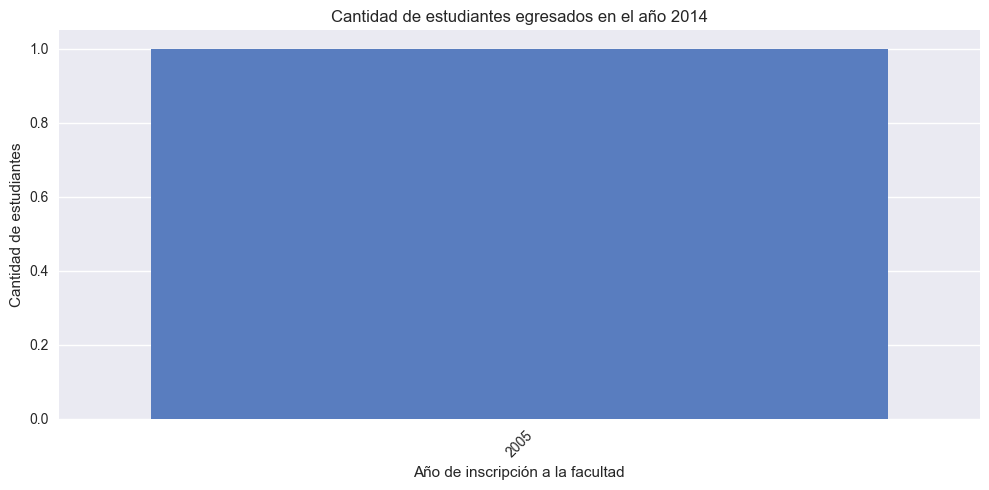

In [17]:
plot_optativas_por_anio(cantidad_optativas, df_obligatorias, 3)

In [18]:
egresados = get_egresados(
    carreras=['Licenciatura en Ciencias de la Computación'],
    anio=2014,
    path_yaml='../../constants/materias_computacion.yaml',
    min_materias_obligatorias = 15,
    min_materias_optativas = 3,
)

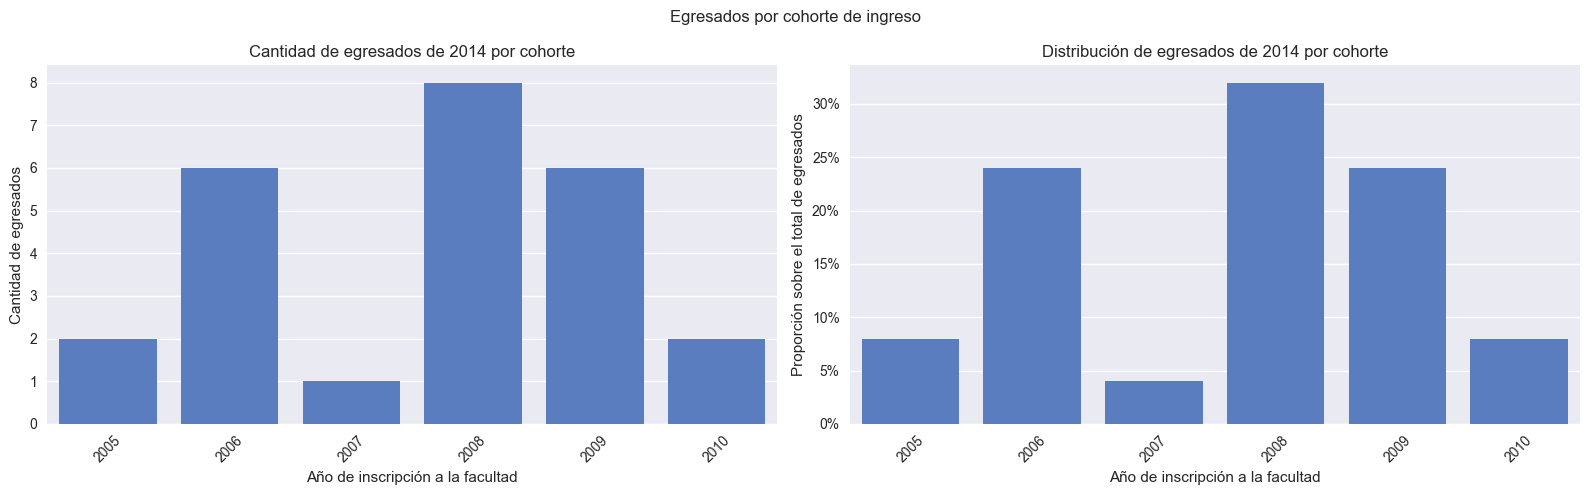

In [19]:
plot_egresados_por_anio(egresados, 2014)

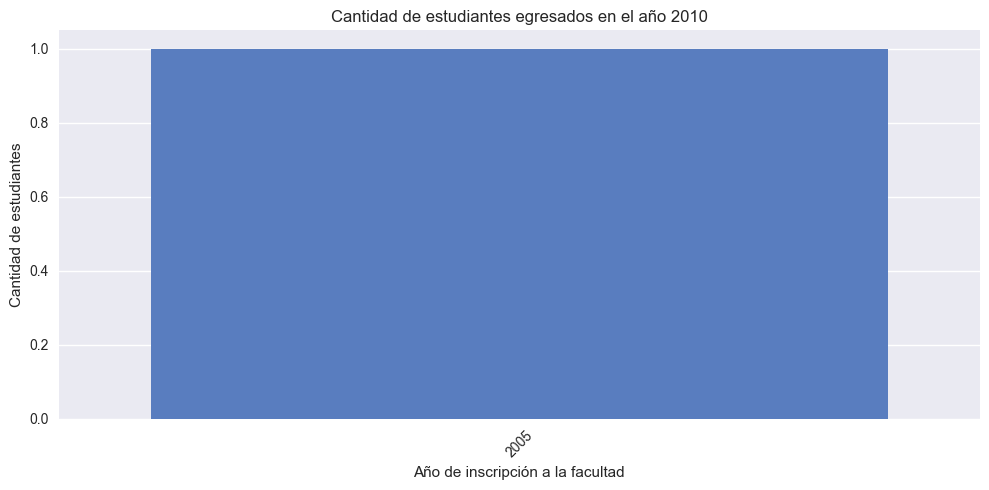

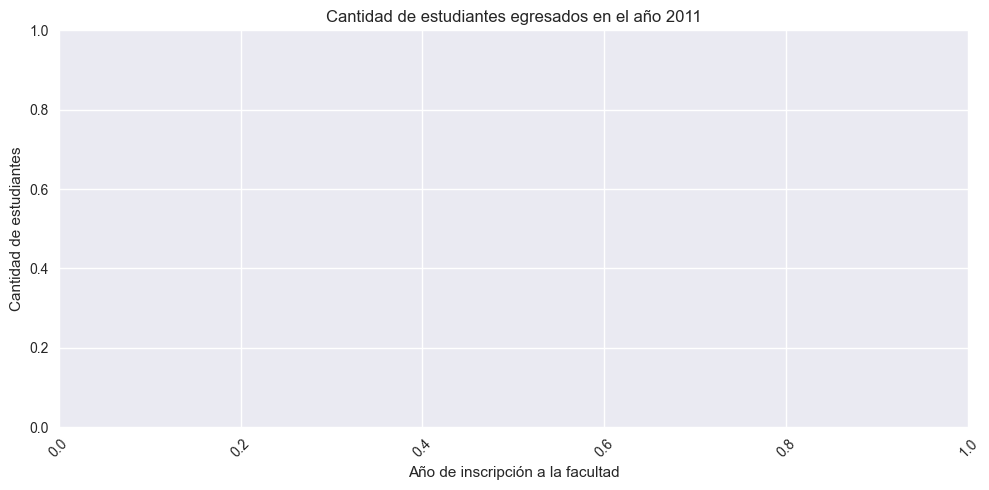

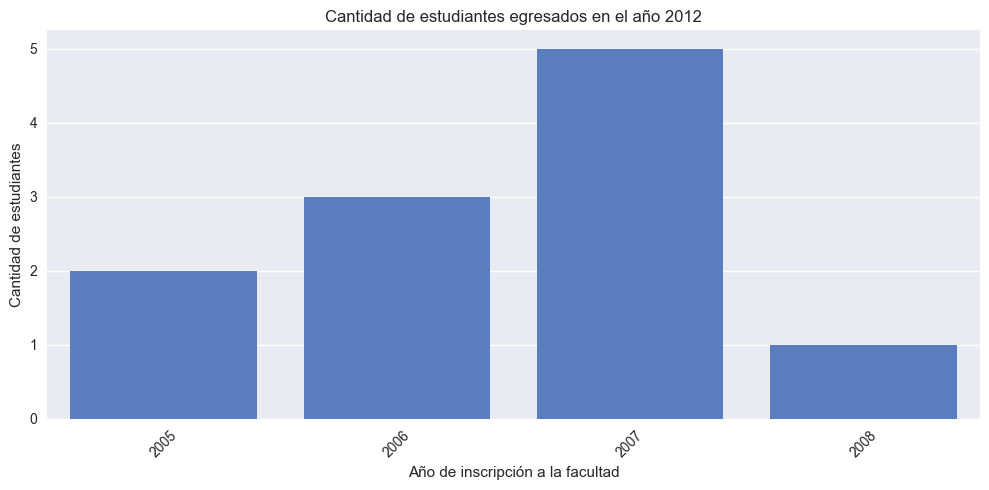

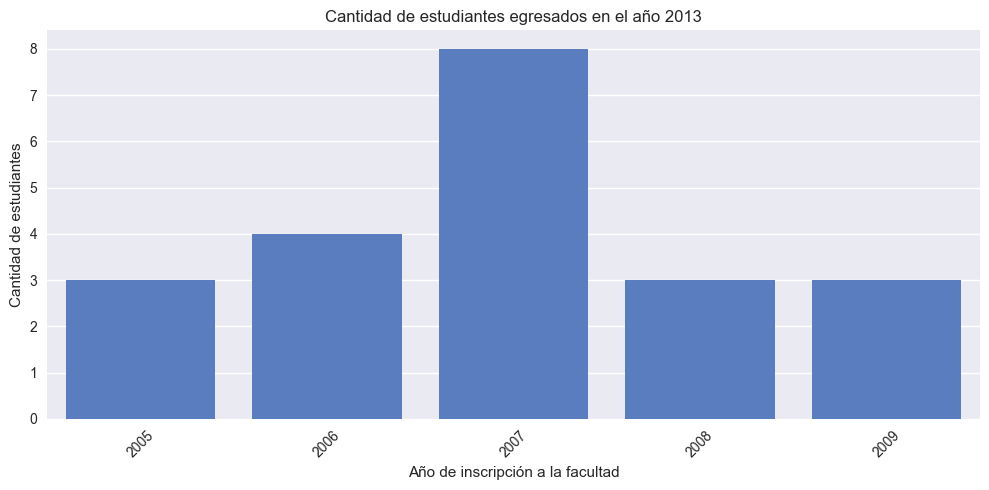

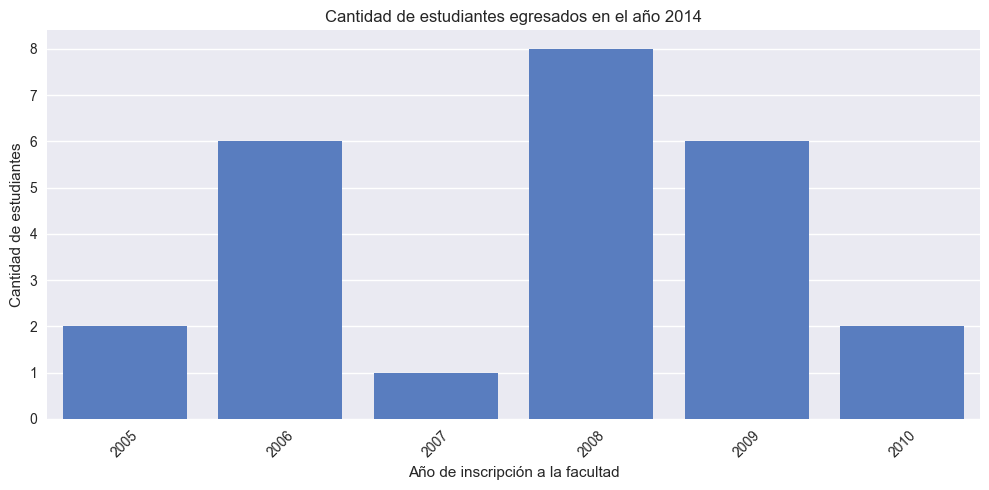

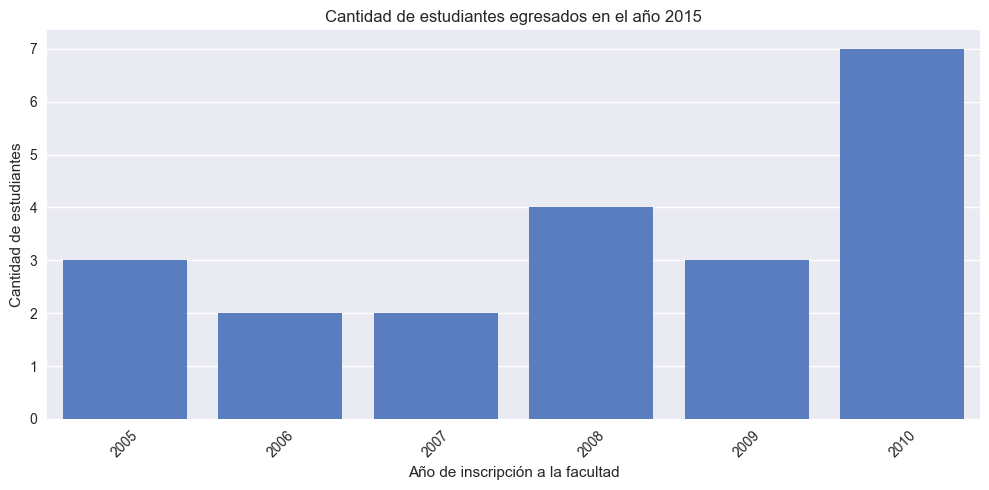

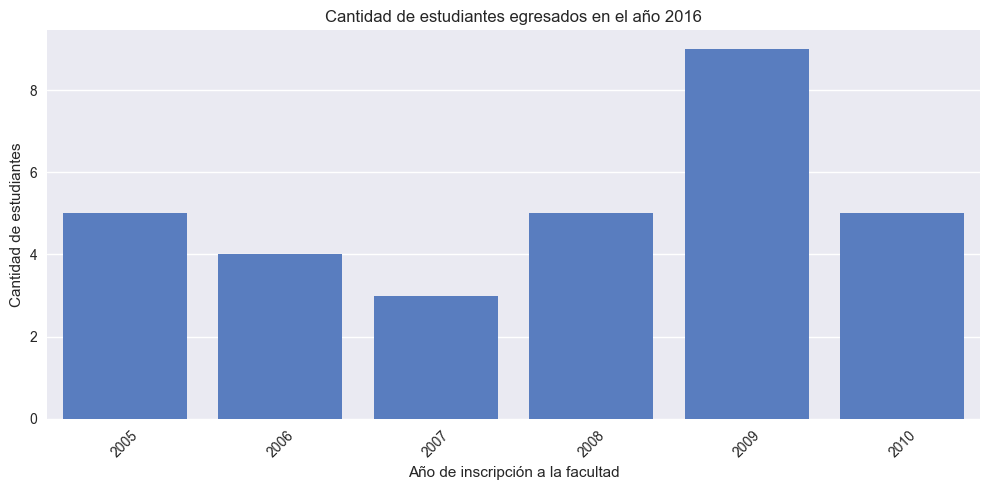

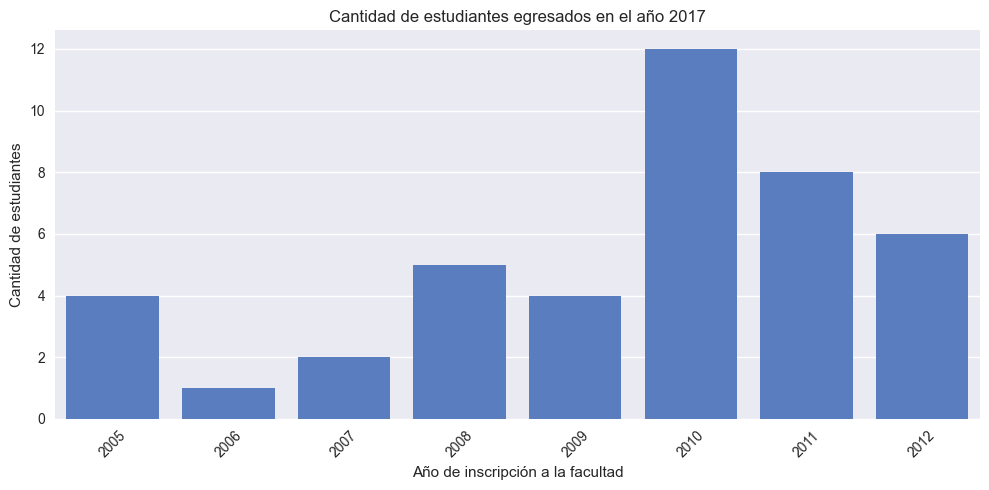

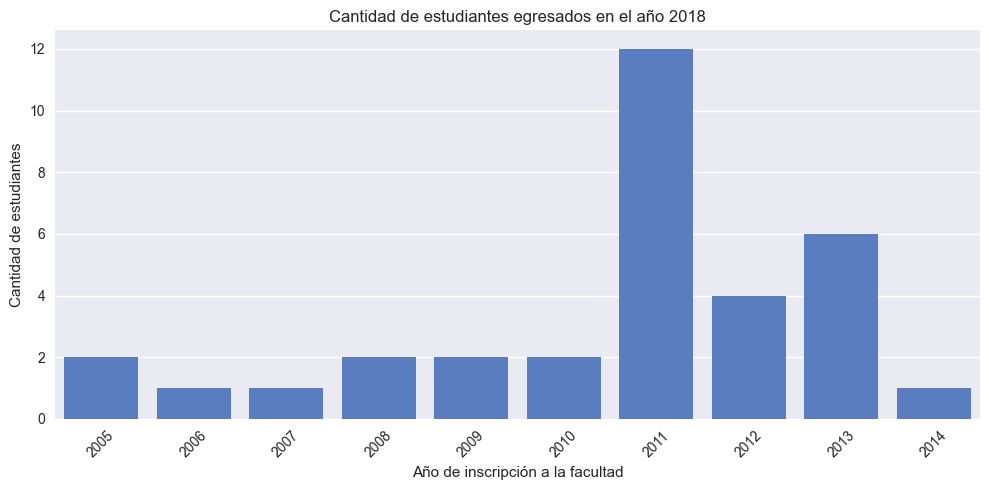

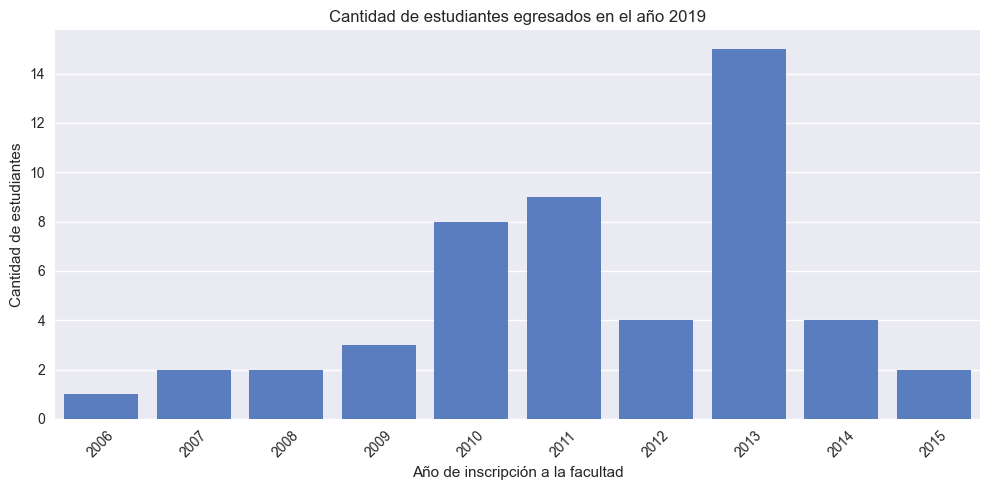

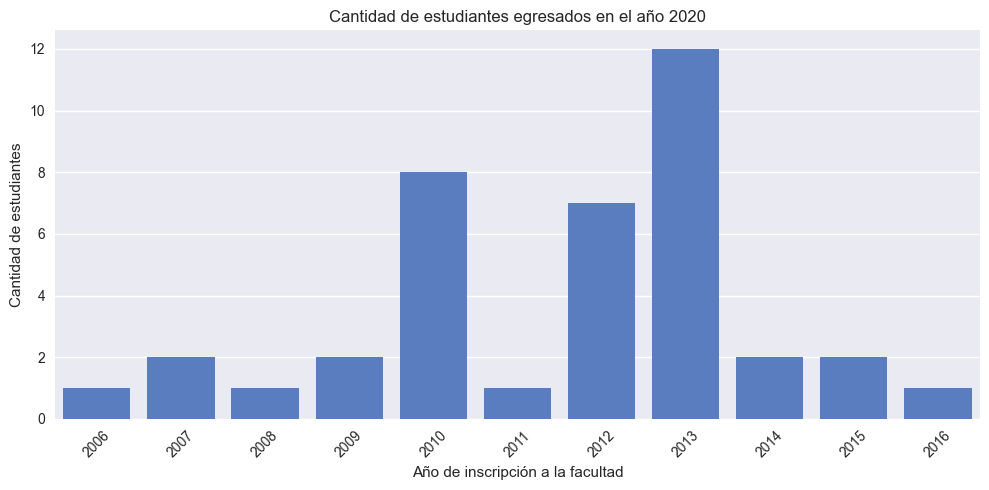

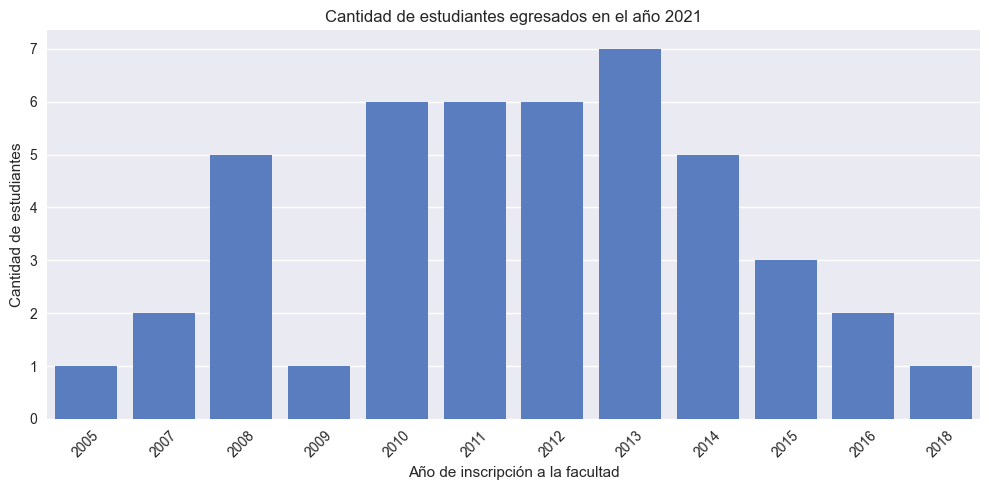

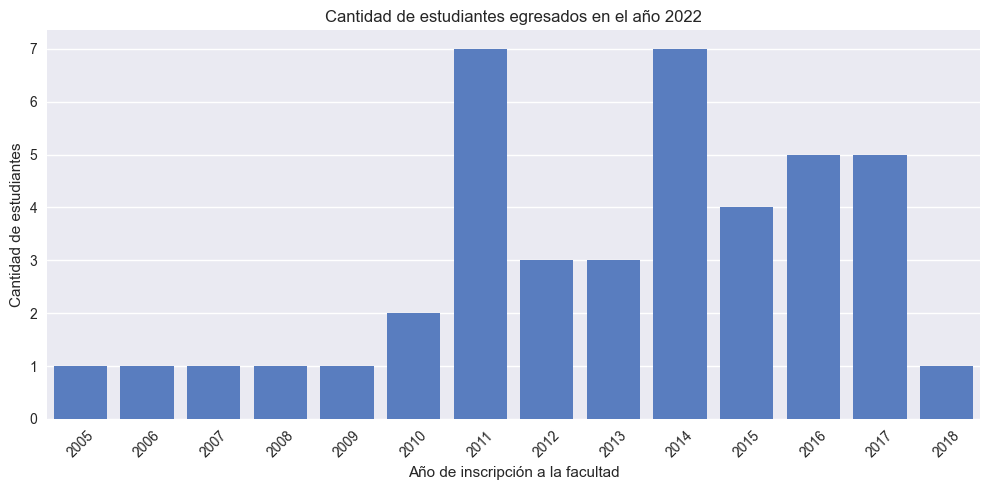

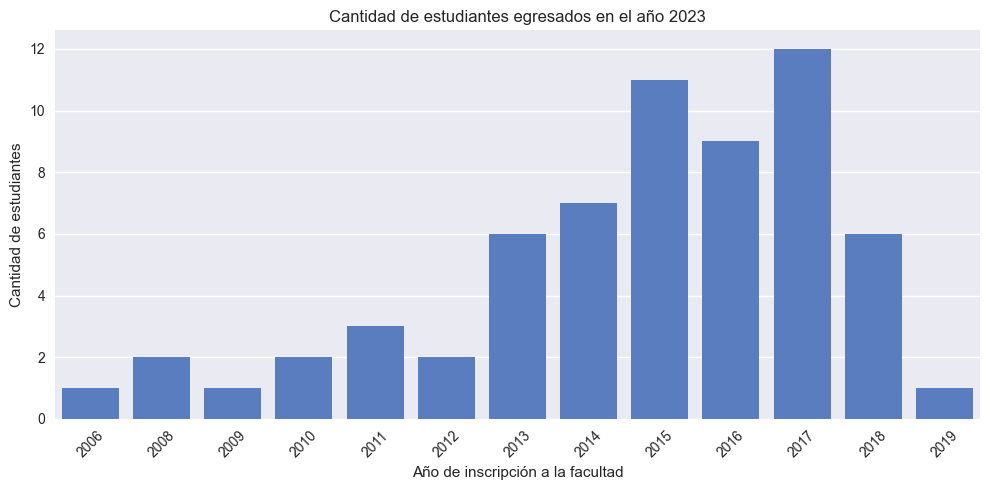

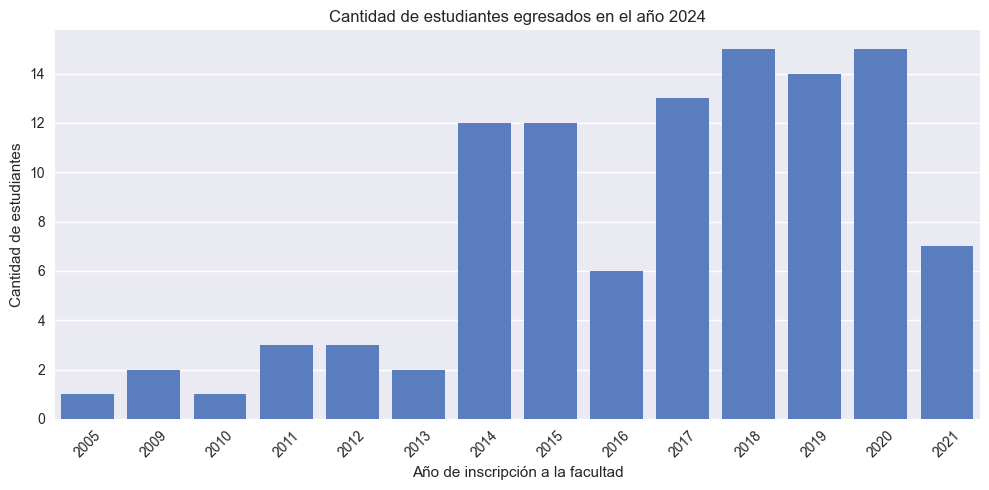

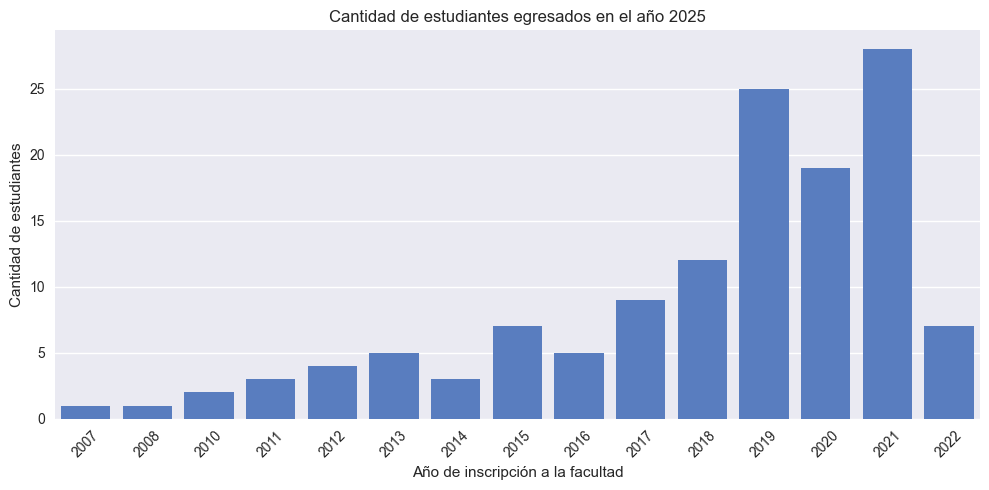

In [20]:
for anio in range(2010, 2026):
    df_obligatorias = get_porcentaje_aprobadas(
                        carreras=['Licenciatura en Ciencias de la Computación'],
                        anio=anio,
                        path_yaml='../../constants/materias_computacion.yaml'
    )
    cantidad_optativas = get_materias_fuera_de_carrera(
                            df_porcentaje=df_obligatorias,
                            path_yaml='../../constants/materias_computacion.yaml',
                            min_materias_aprobadas=15
    )
    plot_optativas_por_anio(cantidad_optativas, df_obligatorias, 3, anio)

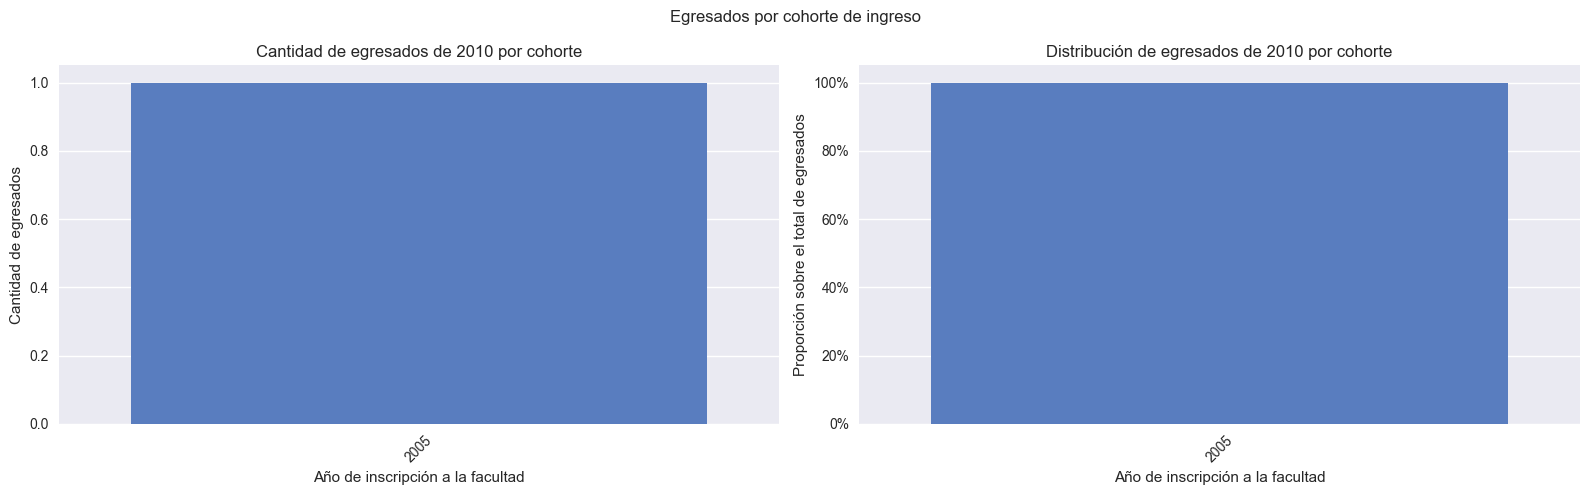

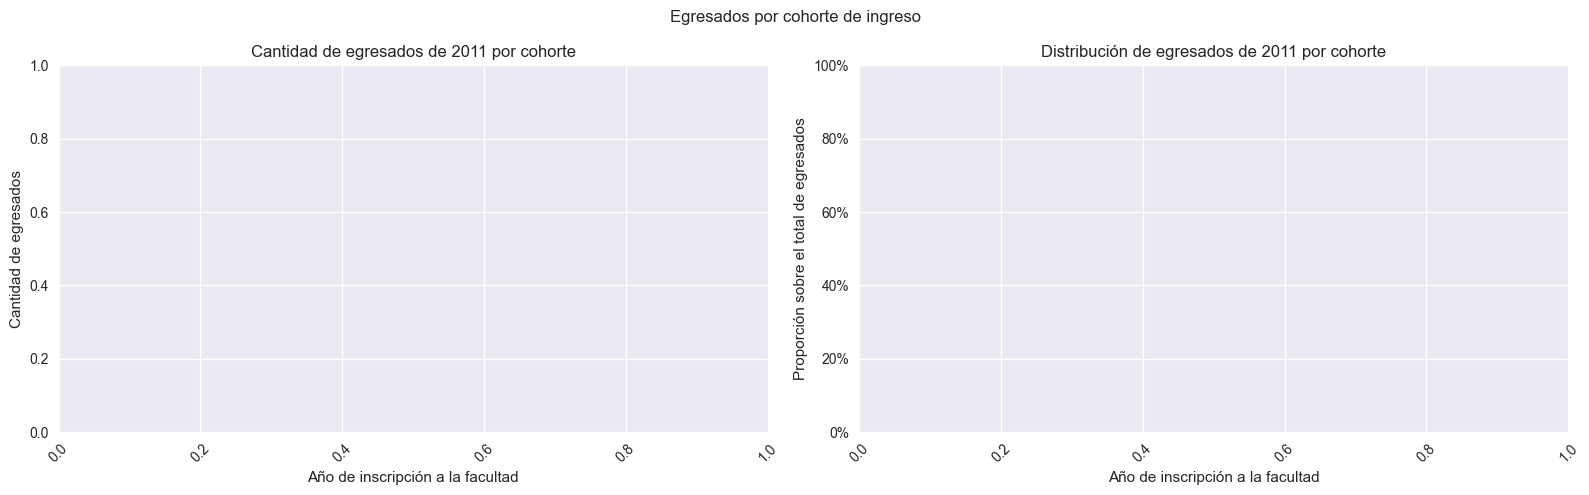

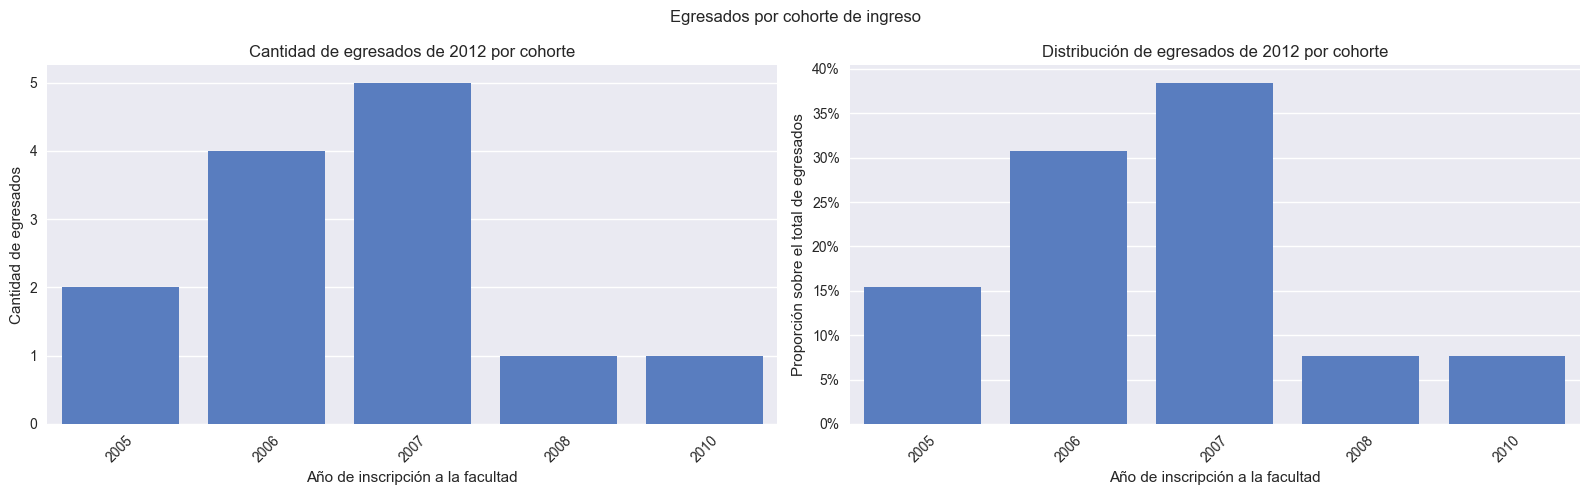

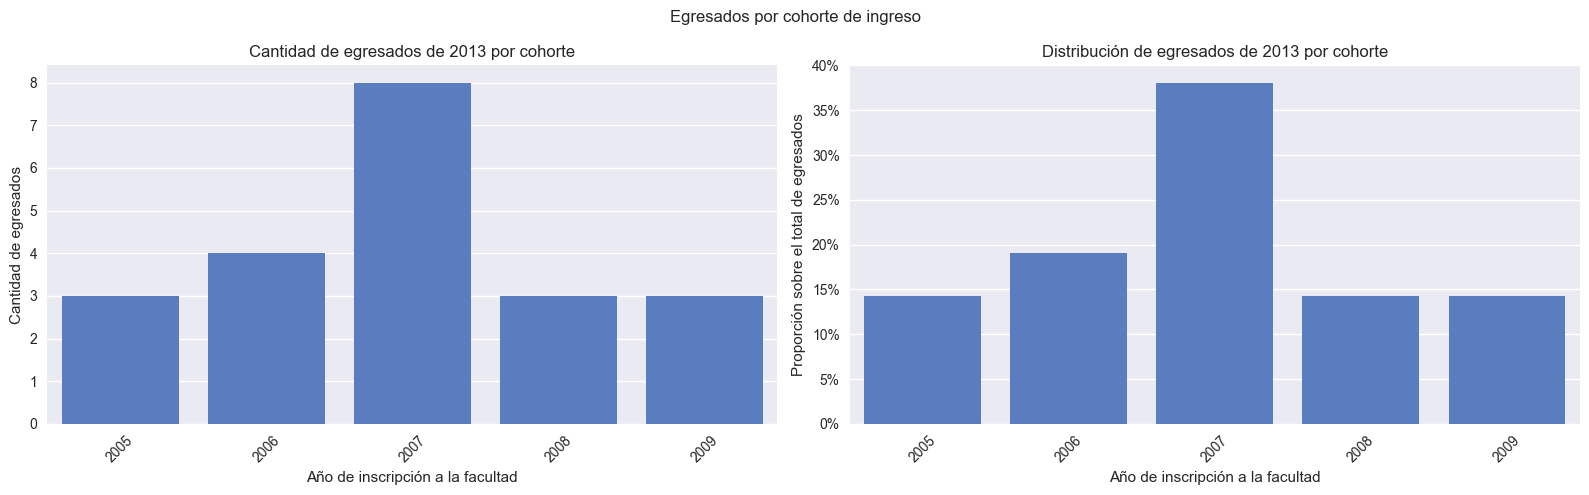

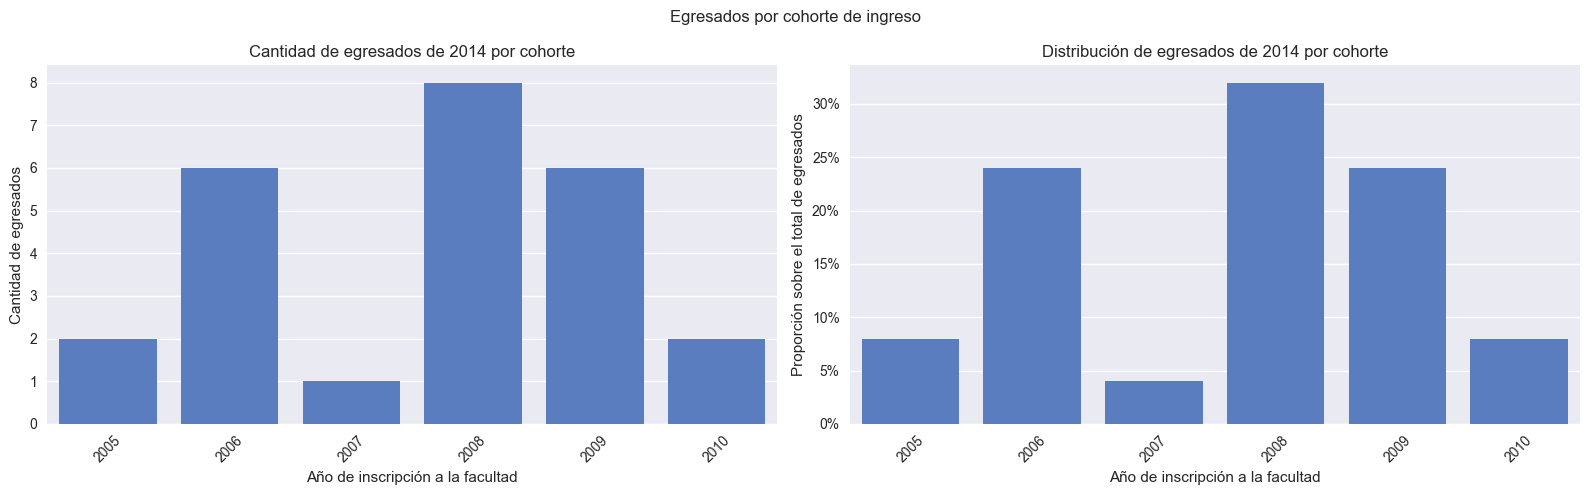

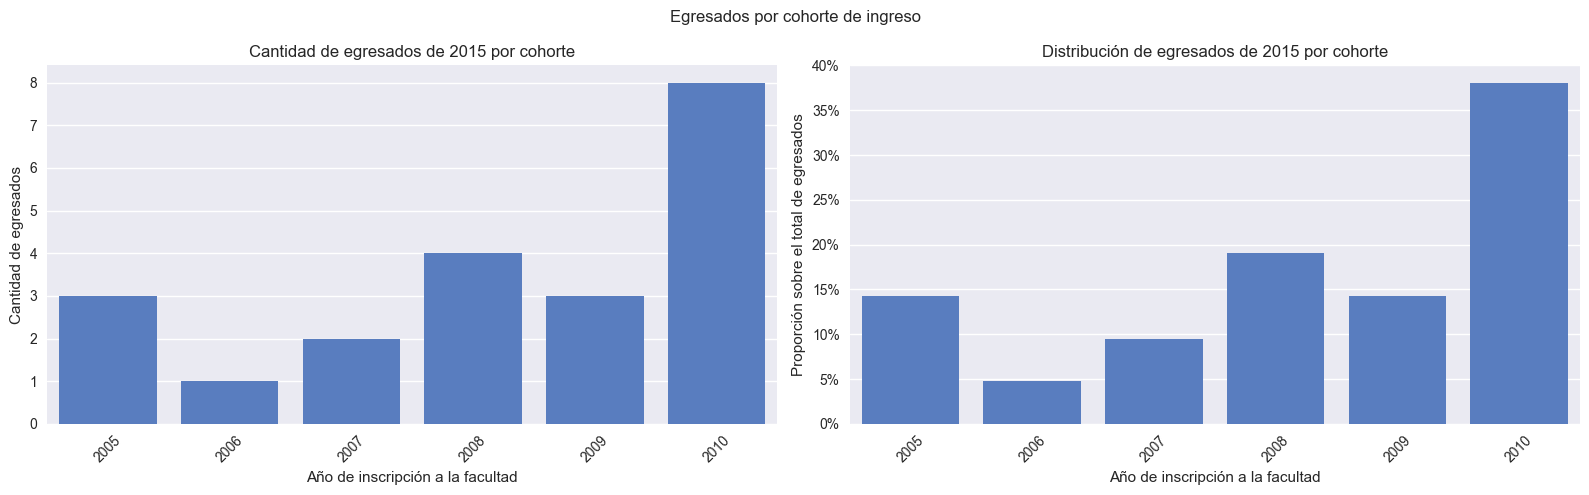

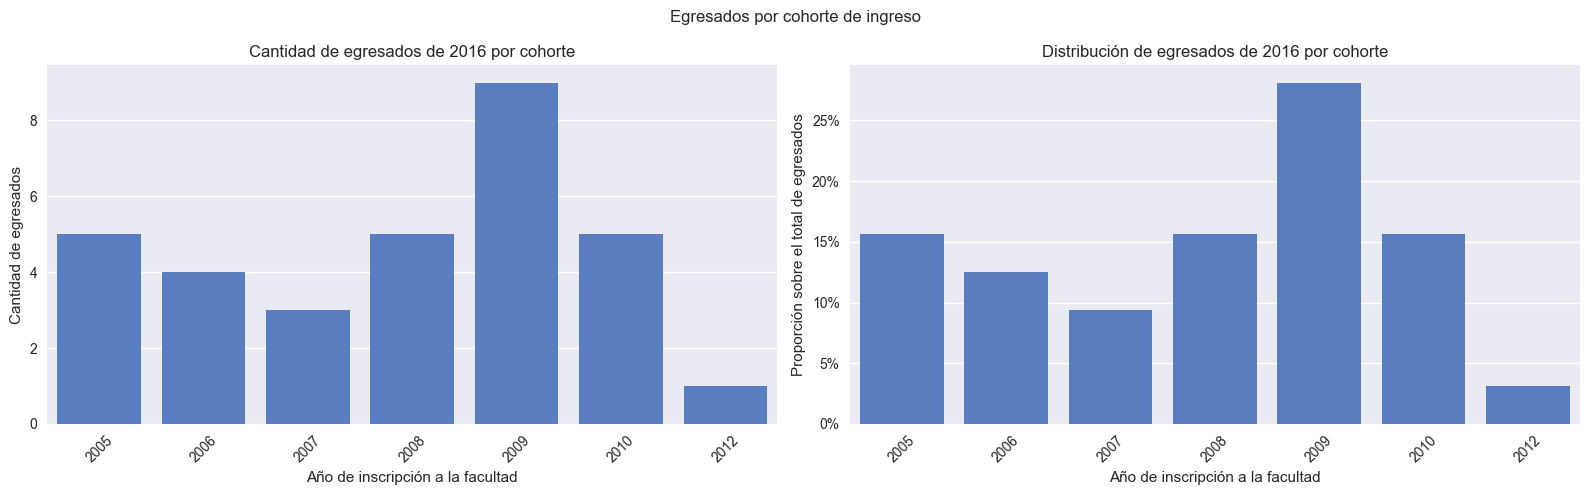

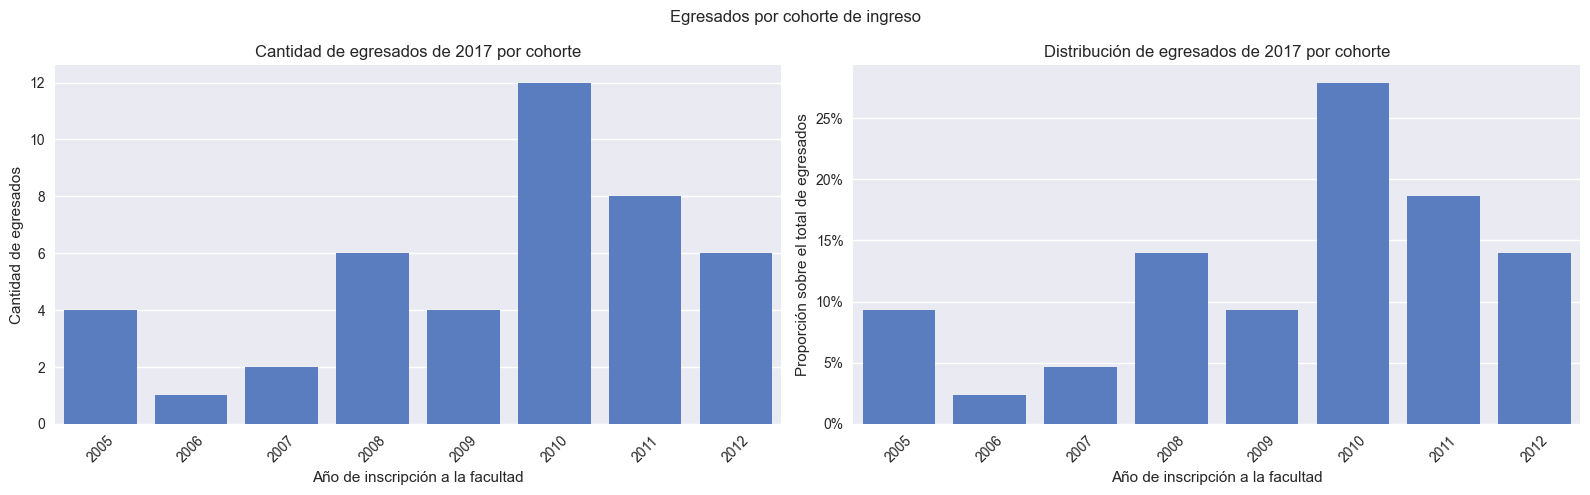

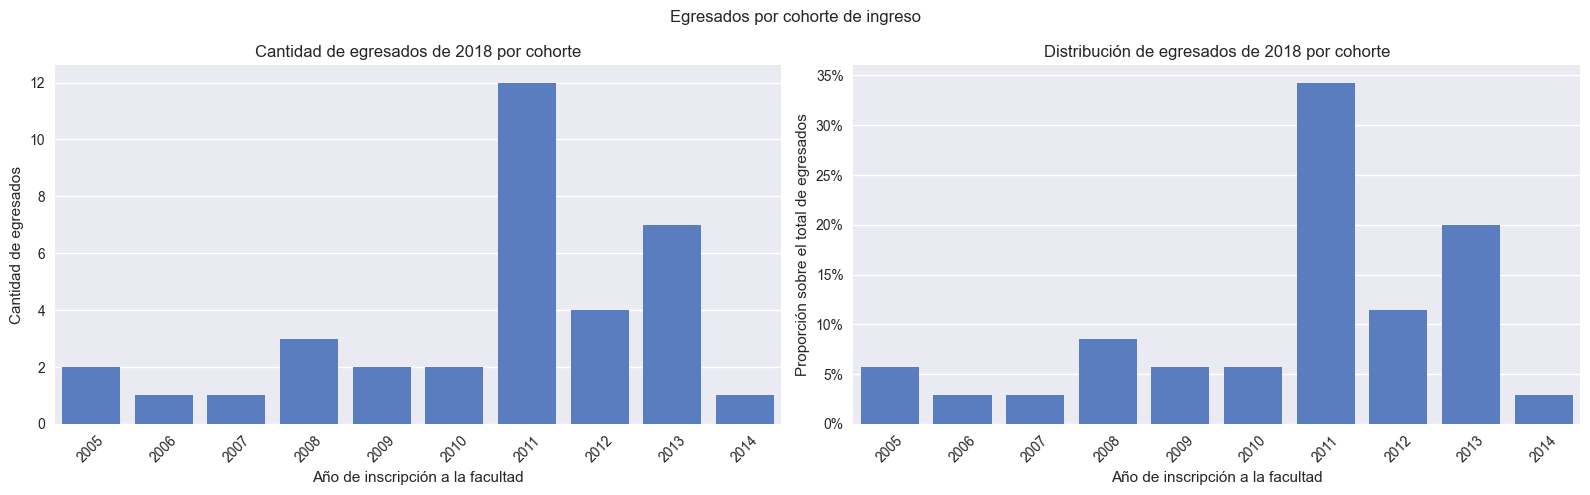

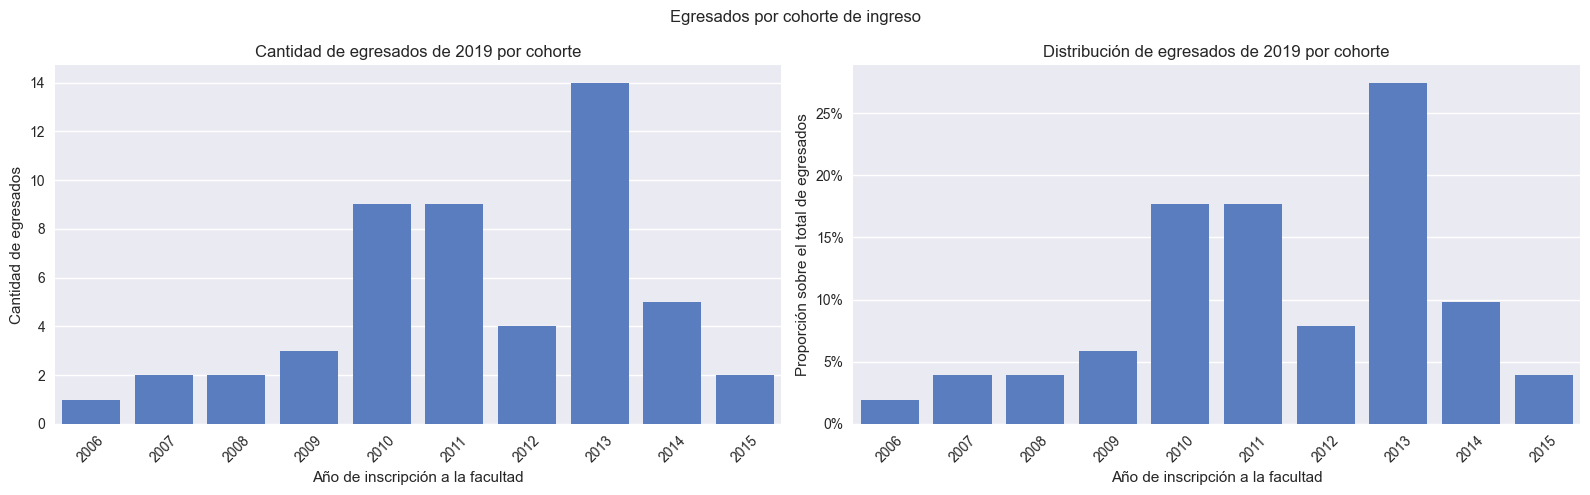

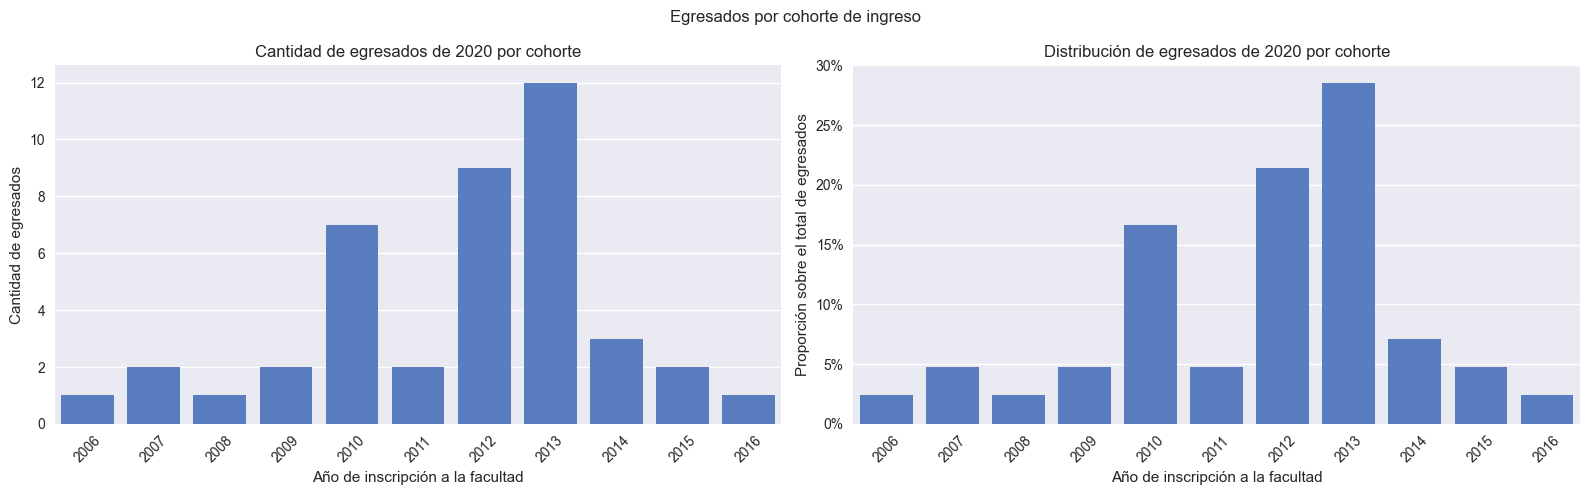

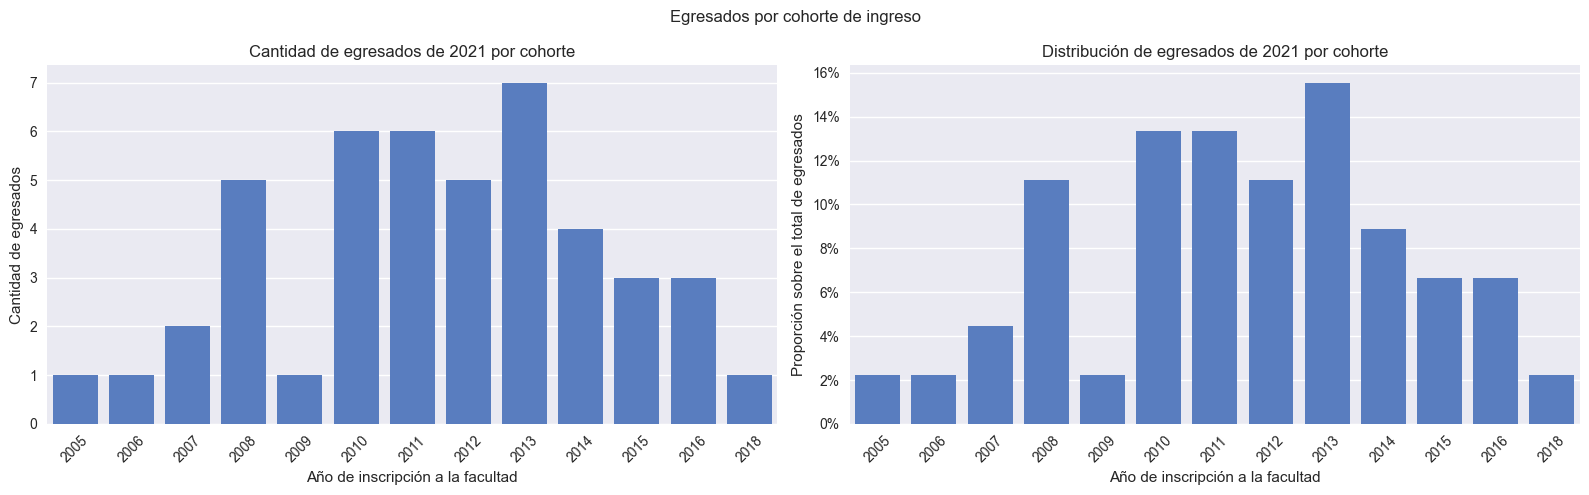

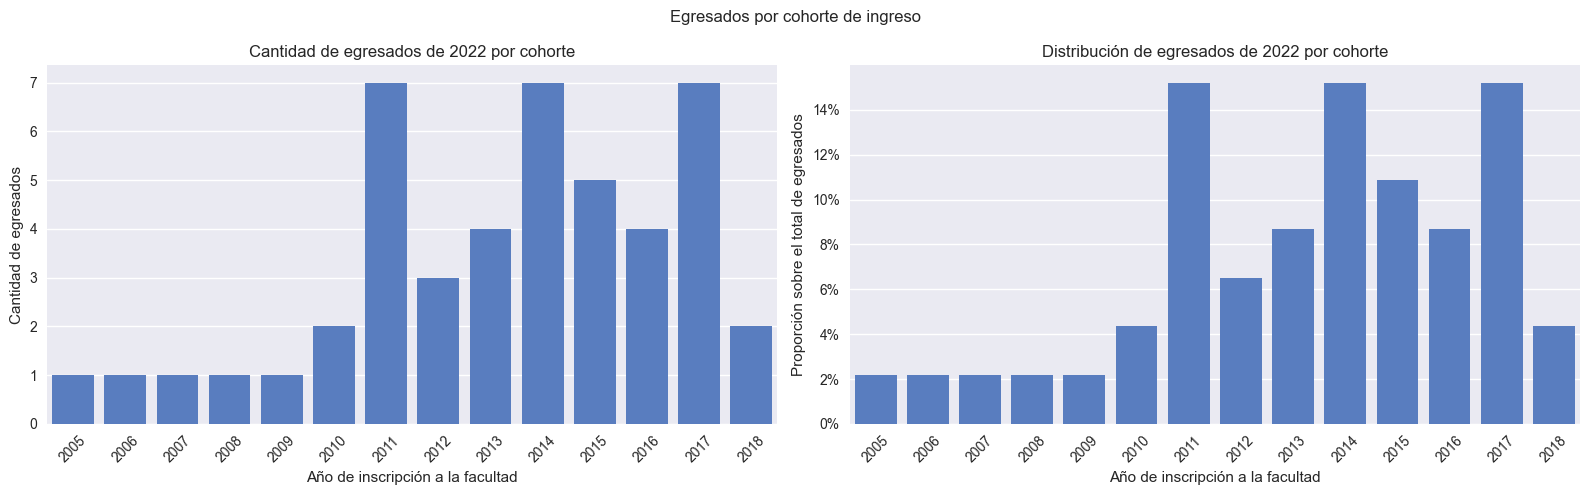

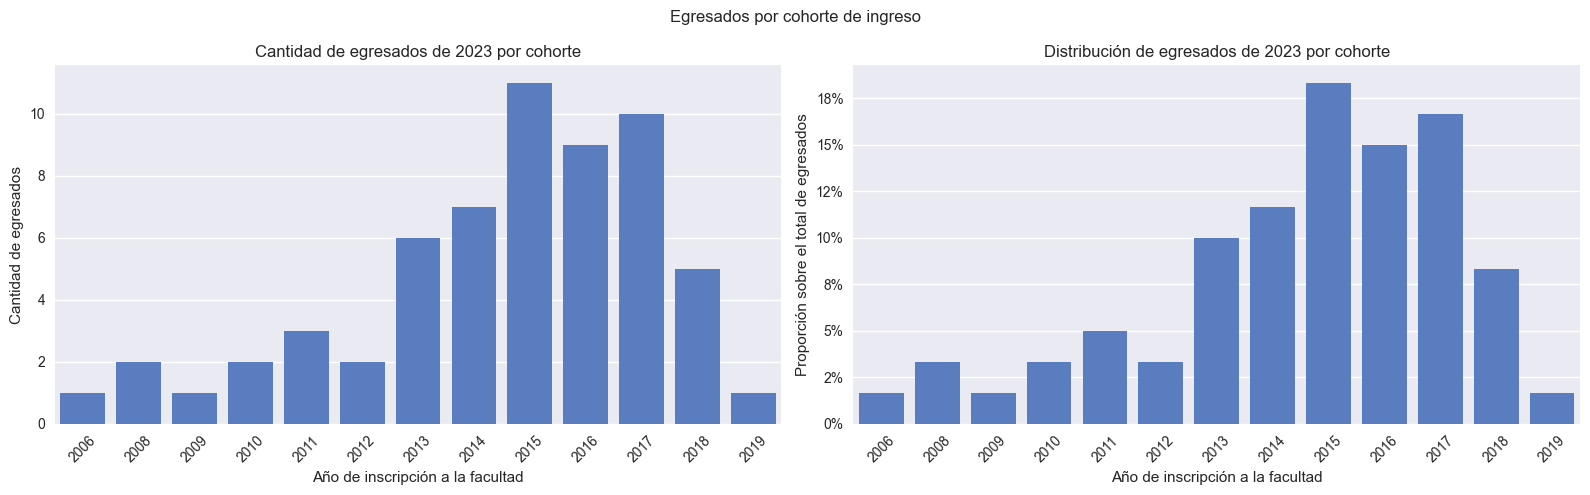

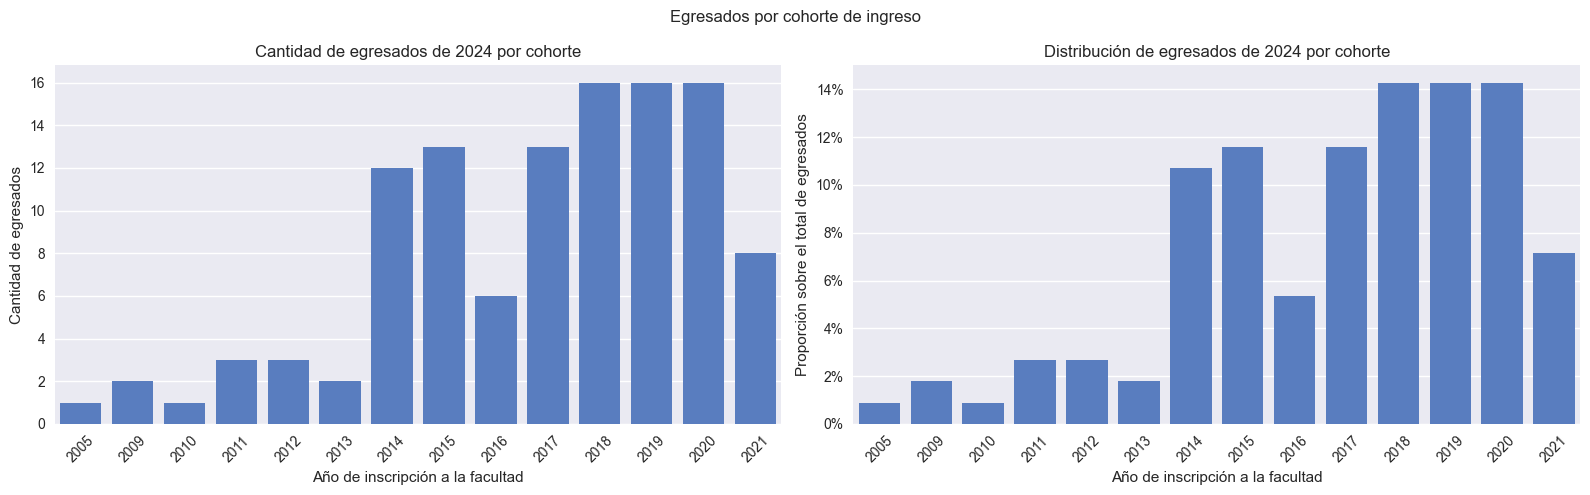

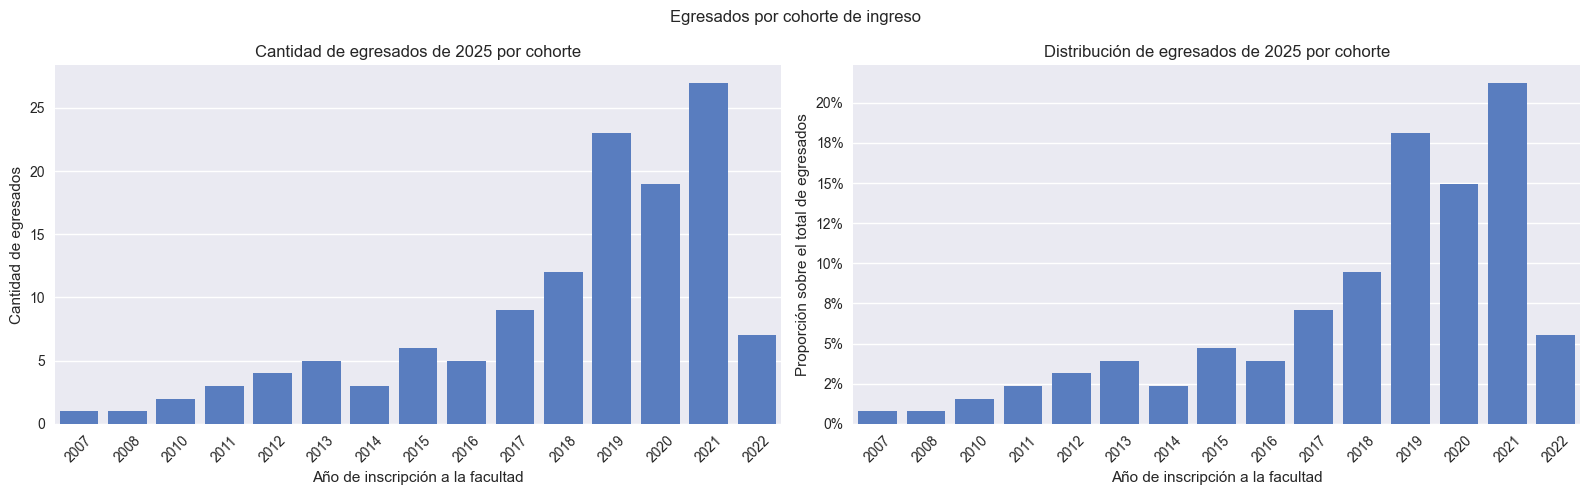

In [21]:
for anio in range(2010, 2026):
    egresados = get_egresados(
    carreras=['Licenciatura en Ciencias de la Computación'],
    anio=anio,
    path_yaml='../../constants/materias_computacion.yaml',
    min_materias_obligatorias = 15,
    min_materias_optativas = 3,
    todos_los_planes = False
    )
    plot_egresados_por_anio(egresados, anio)

In [27]:
todas_las_cohortes = []

for anio in range(2014, 2020):
    egresados = get_egresados(
        carreras=['Licenciatura en Ciencias de la Computación'],
        anio=anio,
        path_yaml='../../constants/materias_computacion.yaml',
        min_materias_obligatorias=15,
        min_materias_optativas=3,
        todos_los_planes=False
    )
    egresados['tiempo_cursando'] = anio - egresados['año_inscripcion_facultad'] + 1
    egresados['año_egreso'] = anio
    todas_las_cohortes.append(egresados)

df_todos = pd.concat(todas_las_cohortes, ignore_index=True)

tabla_tiempo_cursando = (
    df_todos.groupby('tiempo_cursando')['dni']
    .count()
    .reset_index()
    .rename(columns={'dni': 'total_egreso'})
    .sort_values('tiempo_cursando')
    .reset_index(drop=True)
)

tabla_tiempo_cursando

,tiempo_cursando,total_egreso
0,5,6
1,6,32
2,7,42
3,8,42
4,9,28
5,10,23
6,11,15
7,12,9
8,13,7
9,14,3


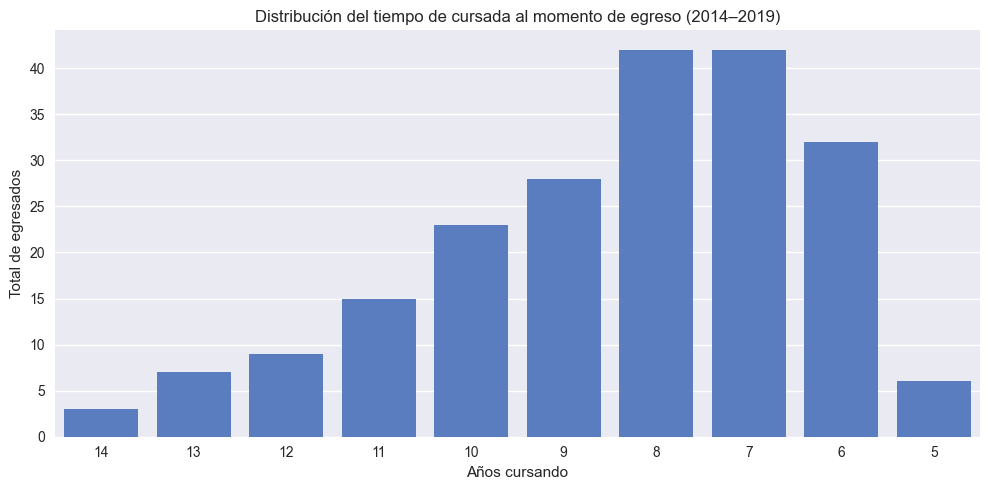

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

orden = tabla_tiempo_cursando.sort_values('tiempo_cursando', ascending=False)['tiempo_cursando'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tabla_tiempo_cursando, x='tiempo_cursando', y='total_egreso', order=orden, ax=ax)
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019)')
plt.tight_layout()
plt.show()


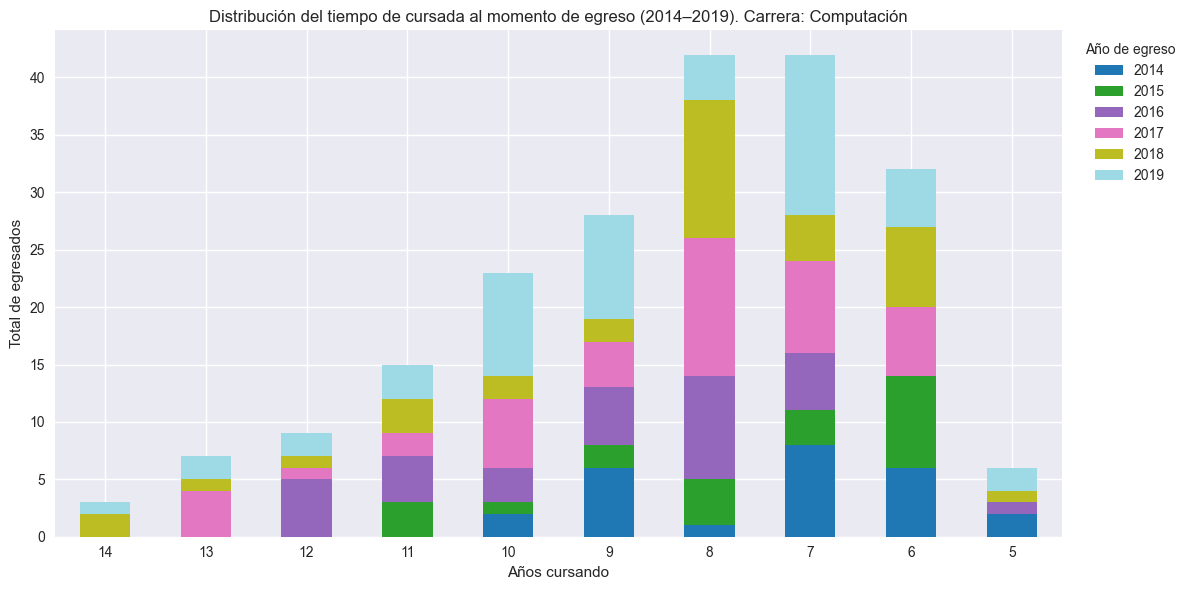

In [29]:
pivot = (
    df_todos.groupby(['tiempo_cursando', 'año_egreso'])['dni']
    .count()
    .unstack(fill_value=0)
)

# orden descendente en el eje x
pivot = pivot.loc[sorted(pivot.index, reverse=True)]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019). Carrera: Computación')
ax.legend(title='Año de egreso', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
